<center><h2 style="color:#0000ff; font-family:Georgia;"><b>DATA 645. Neural Networks and Deep Learning</b></h2>
<h2 style="color:#ff0000; font-family:'Calibri';">Module 10 Homework Lab</h2>
<h1 style="color:#9933cc; font-family:Arial;"><b>Image Segmentation<br></b></h1></center>

In this assignment, you will explore image segmentation using a real dataset of animal photos. You will learn to:
- Load and preprocess image and mask data,
- Train a convolutional neural network (CNN) to predict object masks,
- Visualize the predictions of your model.

We will use the Oxford-IIIT Pet Dataset, which contains images of pets and segmentation masks identifying the pet in each photo.

### Exercise 1: Dataset Loading and Preprocessing
Tasks:

1.1. Load the Oxford-IIIT Pet Dataset from TensorFlow Datasets.

1.2. Inspect a few examples: display the original image and its segmentation mask side by side using matplotlib.

1.3. Resize all images and masks to 128×128 pixels. Normalize the image pixel values to be between 0 and 1.

1.4. Convert the segmentation mask into a binary mask (i.e., set the background to 0 and the pet area to 1).

Hint: The original masks have values 1 (foreground), 2 (pet), and 3 (border). You can use a threshold like mask > 1.

# 1.1. Load the Oxford-IIIT Pet Dataset from TensorFlow Datasets.

In [15]:
# 1.1 
import urllib.request
import tarfile

# URLs of the files to download
image_url = "http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
annotations_url = "http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

# Downloading the files
urllib.request.urlretrieve(image_url, "images.tar.gz")
urllib.request.urlretrieve(annotations_url, "annotations.tar.gz")

# Extracting the downloaded files
with tarfile.open("images.tar.gz", "r:gz") as tar:
    tar.extractall()
    
with tarfile.open("annotations.tar.gz", "r:gz") as tar:
    tar.extractall()

C:\Users\mcphe\AppData\Local\Temp\ipykernel_49260\2948220673.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()
C:\Users\mcphe\AppData\Local\Temp\ipykernel_49260\2948220673.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [16]:
import os

input_dir = "images/"
target_dir = "annotations/trimaps/"

input_img_paths = sorted(
    [os.path.join(input_dir, fname)
     for fname in os.listdir(input_dir)
     if fname.endswith(".jpg")])
target_paths = sorted(
    [os.path.join(target_dir, fname)
     for fname in os.listdir(target_dir)
     if fname.endswith(".png") and not fname.startswith(".")])

# 1.2. Inspect a few examples: display the original image and its segmentation mask side by side using matplotlib.

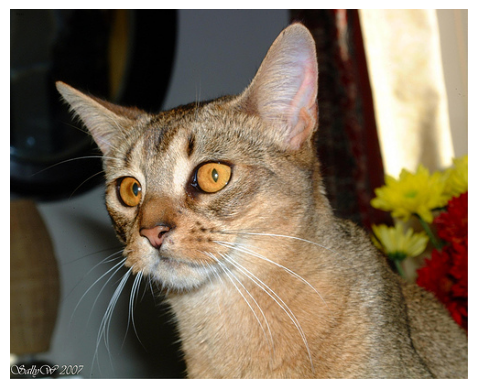

In [17]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

plt.axis("off")
plt.imshow(load_img(input_img_paths[10]))

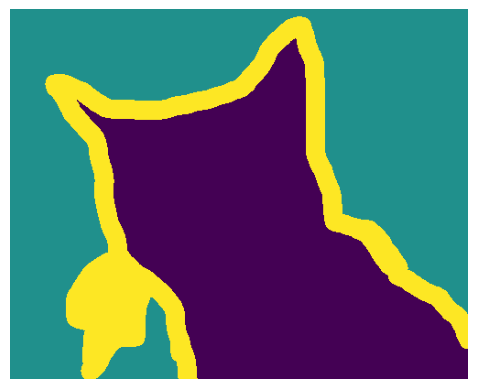

In [18]:
def display_target(target_array):
    normalized_array = (target_array.astype("uint8") - 1) * 127
    plt.axis("off")
    plt.imshow(normalized_array[:, :, 0])

img = img_to_array(load_img(target_paths[10], color_mode="grayscale"))
display_target(img)

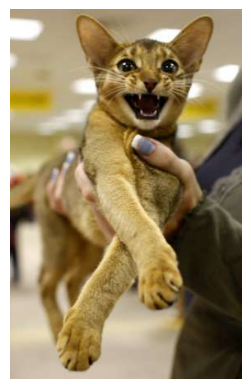

In [19]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

plt.axis("off")
plt.imshow(load_img(input_img_paths[11]))

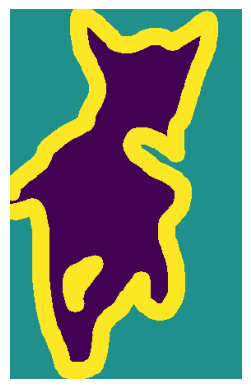

In [20]:
def display_target(target_array):
    normalized_array = (target_array.astype("uint8") - 1) * 127
    plt.axis("off")
    plt.imshow(normalized_array[:, :, 0])

img = img_to_array(load_img(target_paths[11], color_mode="grayscale"))
display_target(img)

# 1.3. Resize all images and masks to 128×128 pixels. Normalize the image pixel values to be between 0 and 1.

In [23]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img_size = (128, 128)

x_list = []
y_list = []
skipped = []

for img_path, mask_path in zip(input_img_paths, target_paths):
    try:
        # Resize image to 128x128 and normalize to [0, 1]
        img = load_img(img_path, target_size=img_size)
        x = img_to_array(img) / 255.0

        # Resize mask to 128x128 (nearest keeps class labels intact)
        mask = load_img(mask_path, target_size=img_size, color_mode="grayscale", interpolation="nearest")
        y = img_to_array(mask)

        x_list.append(x)
        y_list.append(y)
    except (PermissionError, OSError) as error:
        skipped.append((img_path, mask_path, str(error)))

x_data = np.stack(x_list).astype("float32")
y_data = np.stack(y_list).astype("uint8")

print("x_data:", x_data.shape, x_data.min(), x_data.max())
print("y_data:", y_data.shape, np.unique(y_data[:5]))
print("skipped files:", len(skipped))
if skipped:
    print("first skipped:", skipped[0][0])

x_data: (7390, 128, 128, 3) 0.0 1.0
y_data: (7390, 128, 128, 1) [1 2 3]
skipped files: 0


# 1.4. Convert the segmentation mask into a binary mask (i.e., set the background to 0 and the pet area to 1).

In [24]:
y_data = (y_data == 2).astype("float32")

### Exercise 2: Build a Basic CNN for Segmentation
Tasks:

2.1. Build a convolutional neural network using Keras to take a 128×128 RGB image as input and output a 128×128 grayscale mask (with values between 0 and 1) indicating the pet location.

2.2. Use the following layer types in your model:

- Conv2D  
- MaxPooling2D  
- UpSampling2D  
- Final Conv2D layer with a sigmoid activation.  

In [25]:
from tensorflow import keras
from tensorflow.keras import layers

def get_model(img_size=(128, 128)):
    inputs = keras.Input(shape=img_size + (3,))

    # Encoder
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)   # 64x64
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)   # 32x32

    # Bottleneck
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)

    # Decoder
    x = layers.UpSampling2D(size=(2, 2))(x)        # 64x64
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(size=(2, 2))(x)        # 128x128
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)

    # Binary segmentation output
    outputs = layers.Conv2D(1, 1, activation="sigmoid", padding="same")(x)

    return keras.Model(inputs, outputs)

model = get_model((128, 128))
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,537 (724.75 KB)

 Trainable params: 185,537 (724.75 KB)

 Non-trainable params: 0 (0.00 B)

### Exercise 3: Compile and Train the Model
Tasks:

3.1. Compile your model using the following settings:  
- Loss function: binary_crossentropy
- Optimizer: Adam
- Metric: accuracy

3.2. Train the model for 5–10 epochs on the training dataset and evaluate it on a validation set.

3.3. Plot training and validation accuracy curves using matplotlib.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers


val_count = int(0.2 * len(x_data))
train_input_imgs, val_input_imgs = x_data[:-val_count], x_data[-val_count:]
train_targets, val_targets = y_data[:-val_count], y_data[-val_count:]

inputs = keras.Input(shape=(128, 128, 3))
x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(size=(2, 2))(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(size=(2, 2))(x)
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
outputs = layers.Conv2D(1, 1, activation="sigmoid", padding="same")(x)
model = keras.Model(inputs, outputs)

print("output shape:", model.output_shape, "target shape:", train_targets.shape)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint("oxford_segmentation.keras", save_best_only=True)
],

history = model.fit(
    train_input_imgs, train_targets,
    epochs=5,
    callbacks=callbacks,
    batch_size=16,
    validation_data=(val_input_imgs, val_targets)
 )

output shape: (None, 128, 128, 1) target shape: (5912, 128, 128, 1)
Epoch 1/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 190s 500ms/step - accuracy: 0.7359 - loss: 0.5245 - val_accuracy: 0.7923 - val_loss: 0.4452
Epoch 2/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 173s 468ms/step - accuracy: 0.7852 - loss: 0.4575 - val_accuracy: 0.8141 - val_loss: 0.4072
Epoch 3/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 165s 445ms/step - accuracy: 0.8050 - loss: 0.4261 - val_accuracy: 0.8014 - val_loss: 0.4319
Epoch 4/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 163s 441ms/step - accuracy: 0.8140 - loss: 0.4089 - val_accuracy: 0.8388 - val_loss: 0.3644
Epoch 5/5
370/370 ━━━━━━━━━━━━━━━━━━━━ 162s 437ms/step - accuracy: 0.8192 - loss: 0.4008 - val_accuracy: 0.8354 - val_loss: 0.3662


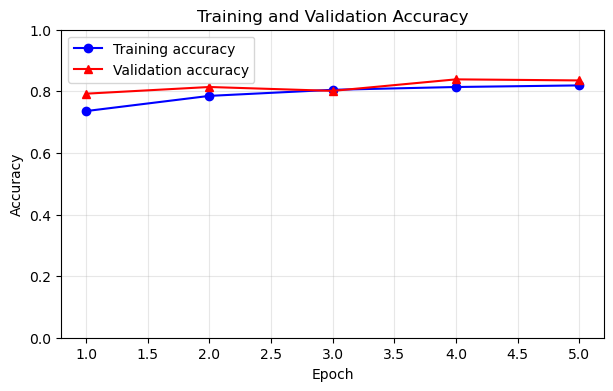

In [27]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, acc, "bo-", label="Training accuracy")
plt.plot(epochs, val_acc, "r^-", label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Exercise 4: Predict and Visualize Masks
Tasks:

4.1. Pick a few test images from the dataset and use your trained model to predict their segmentation masks.

4.2. For each image, show:  
- The original image,
- The ground truth mask,
- The predicted mask (binarized: pixel value > 0.5 is pet, else background).

Hint: Use plt.imshow() with cmap='gray' for masks.

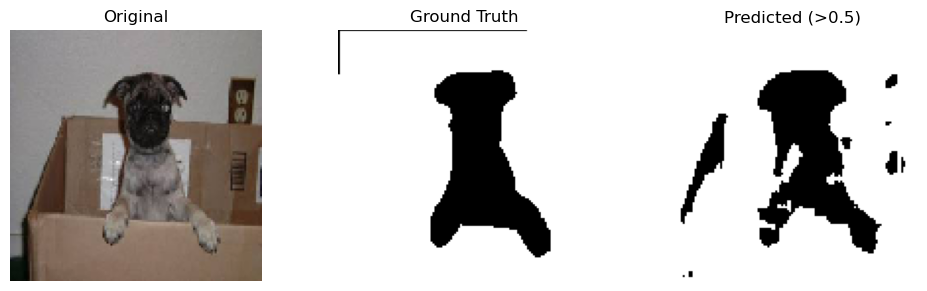

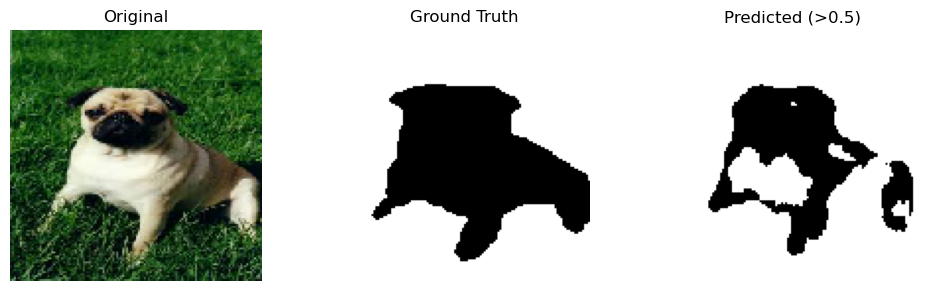

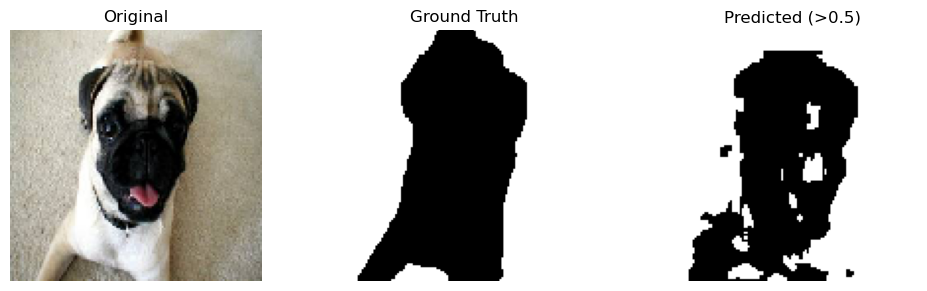

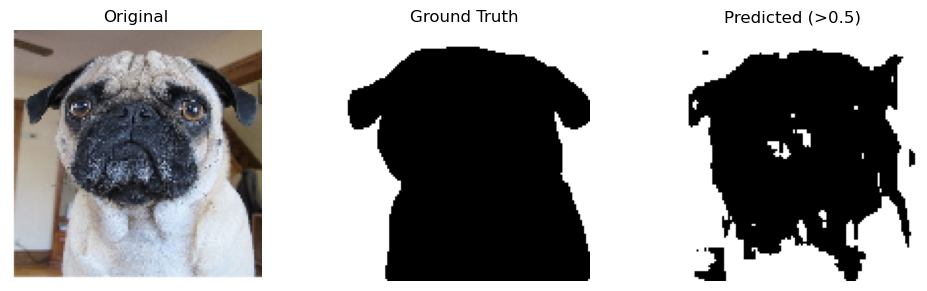

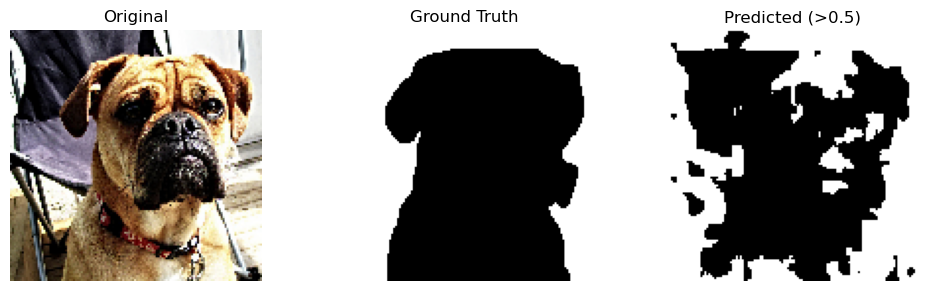

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import array_to_img

n = 5 

for i in range(n):
    img = val_input_imgs[i]
    gt = val_targets[i, :, :, 0]

    pred_prob = model.predict(np.expand_dims(img, 0), verbose=0)[0, :, :, 0]
    pred_bin = (pred_prob > 0.5).astype("float32")

    plt.figure(figsize=(10, 3))

    plt.subplot(1, 3, 1)
    plt.imshow(array_to_img(img))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_bin, cmap="gray")
    plt.title("Predicted (>0.5)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()